# Analyses v2.2

In [1480]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import analyses.spc as spc
import analyses.linreg as linreg
import analyses.pfr as pfr
import analyses.mwr as mwr 
import analyses.r1_intrusion as r1_intrusion
import analyses.rt_init as rt_init
import analyses.pli_eli as pli_eli
import analyses.irt as irt 
import analyses.tcl as tcl
import analyses.lcrp as lcrp
import analyses.scl as scl
import analyses.statistics as stat_tests
from scipy.stats import wilcoxon
import warnings; warnings.filterwarnings('ignore')
from data.spellcheck import spellcheck_recalls_dl
from data.prolific_quality import filter_sessions_by_quality
from data.recall_inspection import inspect_list_recall

## 0. Load and Clean

In [1481]:
# Loads the most recent pulled CSV file from data/data_storage 
data_dir = Path('data/data_storage') # create path to folder 
try:
    data_path = max(data_dir.glob('dirfru_trials*.csv'), key=lambda p: p.stat().st_mtime) # get most recent trial csv
except ValueError:
    raise FileNotFoundError(f'No dirfru_trials*.csv files found in {data_dir}')
raw = pd.read_csv(data_path)
print(f'Loaded {data_path}')

Loaded data/data_storage/dirfru_trials_20260911_231345.csv


In [1482]:
# Manual Exclusion
exclude_pid = []
print(f'Before exclusion: {len(raw)} rows')
raw = raw[~raw['prolific_pid'].isin(exclude_pid)].copy()
print(f'After exclusion: {len(raw)} rows')
print(f'Excluded data (Prolific IDs: {exclude_pid})')

Before exclusion: 234291 rows
After exclusion: 234291 rows
Excluded data (Prolific IDs: [])


In [1483]:
# Keep only word-presentation and recall rows - analyses.spc_sess / pfr_sess use these
df = raw[raw['type'].isin(['WORD', 'REC_WORD'])].copy()

# Ensure numeric dtypes (raw CSV mixes schemas across rows)
for col in ['serial_position', 'list', 'session', 'l_length', 'rt']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check
type(df['serial_position'].iloc[0]), type(df['list'].iloc[0]), type(df['session'].iloc[0]), type(df['l_length'].iloc[0]), type(df['rt'].iloc[0])

(numpy.float64, numpy.float64, numpy.int64, numpy.int64, numpy.float64)

In [1484]:
# Build lookup: presented WORD -> serial position
word_rows = df[df['type'] == 'WORD'].copy()
word_rows['word_key'] = word_rows['word'].str.lower().str.strip()
word_maps = word_rows.set_index(
    ['prolific_pid', 'session', 'list', 'word_key']
)['serial_position'].to_dict()

# recompute serial positions for REC_WORD
def recover_sp(row):
    if row['type'] != 'REC_WORD':
        return row['serial_position']
    if pd.isna(row['rec_word']) or str(row['rec_word']).strip() in ['', 'null']:
        return 99
    key = (row['prolific_pid'], row['session'], row['list'], str(row['rec_word']).lower().strip())
    return word_maps.get(key, 88) # return serial position if found else 88 

df['serial_position'] = df.apply(recover_sp, axis=1)
df = spellcheck_recalls_dl(df) # add spellcheck following original study, Levenshtein dist <= 1 

Damerau-Levenshtein spellcheck corrected 2602 recall(s).


In [1485]:
df_before_quality = df.copy()
df_after_quality = filter_sessions_by_quality(df_before_quality, raw)

before_sessions = df_before_quality[['prolific_pid', 'session']].drop_duplicates()
after_sessions = df_after_quality[['prolific_pid', 'session']].drop_duplicates()

excluded_sessions = (
    before_sessions
    .merge(after_sessions, on=['prolific_pid', 'session'], how='left', indicator=True)
    .query("_merge == 'left_only'")
    .drop(columns='_merge')
    .sort_values(['prolific_pid', 'session'])
)

excluded = len(excluded_sessions)

print(f"Excluded sessions by quality criteria: {excluded}")
display(excluded_sessions)

df = df_after_quality


Participant 69eb5d9fbfddb861d43a0d0f in session 0 took notes.
Participant 69eb5d9fbfddb861d43a0d0f in session 1 took notes.
Participant 69eb5d9fbfddb861d43a0d0f in session 4 took notes.
Participant 6a178e2e2b82ec7429f2353c in session 3 had 2 trials with zero correct recalls.
Participant stel01 in session 3 had 2 trials with zero correct recalls.
Excluded sessions by quality criteria: 5


,prolific_pid,session
62,69eb5d9fbfddb861d43a0d0f,0
138,69eb5d9fbfddb861d43a0d0f,1
206,69eb5d9fbfddb861d43a0d0f,4
506,6a178e2e2b82ec7429f2353c,3
4,stel01,3


## 1. Inspection

In [1486]:
df = df[df['study_id'] != 'test']
study_ids = df['study_id'].unique()
print(f"Unique study IDs in the dataset: {study_ids}")

Unique study IDs in the dataset: <StringArray>
['6a2767189a4f0e0a29dc9a32', '6a27672e9f42f5fc0f800c49',
 '6a2768acf487b7842842f74c', '6a276962874a96d003489c45',
 '6a2769b25cbe191d4bf90bba', '6a94e3286f8fd3491209112a',
 '6a94e406a70405ad5a421026', '6a94e5555b00e0e80a3ac706',
 '6a94e598703277b3ace1b216', '6a94e5d410e6c6c4deca61c7']
Length: 10, dtype: str


In [1487]:
# temporary code-checking selection

df = df[df['study_id'].isin(['6a94e3286f8fd3491209112a', '6a94e406a70405ad5a421026', '6a94e5555b00e0e80a3ac706', 
                             '6a94e598703277b3ace1b216', '6a94e5d410e6c6c4deca61c7'])]

In [1488]:
# Metadata Inspection
session_info = df[['prolific_pid', 'session', 'initiation_condition']].drop_duplicates(['prolific_pid', 'session'])

# Exclude session 0 before counting toward "included sessions"
included_sessions = session_info[session_info['session'] != 0]

# Count included sessions per participant, keep those with 2+
session_counts = included_sessions.groupby('prolific_pid')['session'].nunique()
twoplus_pids = session_counts[session_counts >= 2].index

# Get one condition label per participant (assumes condition is fixed per participant)
pid_condition = session_info.drop_duplicates('prolific_pid').set_index('prolific_pid')['initiation_condition']

twoplus_conditions = pid_condition.loc[twoplus_pids]

print(f'{len(df)} rows across {session_info["prolific_pid"].nunique()} participants, {len(session_info)} sessions')
print(f"Condition breakdown by session: {session_info['initiation_condition'].value_counts().to_dict()}")
print(f'Participants with 2+ included sessions: {len(twoplus_pids)}')
print(f"Condition breakdown for participants with 2+ included sessions: {twoplus_conditions.value_counts().to_dict()}")

print("Total Sessions Completed:", session_info['session'].nunique())
counts = session_info['session'].value_counts().sort_index()
counts.index = [f"Session {i}" for i in counts.index]
print(counts)

106896 rows across 89 participants, 295 sessions
Condition breakdown by session: {'primacy': 116, 'recency': 104, 'free': 75}
Participants with 2+ included sessions: 57
Condition breakdown for participants with 2+ included sessions: {'recency': 23, 'primacy': 20, 'free': 14}
Total Sessions Completed: 5
Session 0    88
Session 1    73
Session 2    58
Session 3    47
Session 4    29
Name: count, dtype: int64


In [1489]:
# Per-Subject Inspection
pid = '69ae40f1b37b0e141294f003' # (replace with actual Prolific ID of interest)

# 1) Number of sessions completed
n_sessions = session_info[session_info['prolific_pid'] == pid]['session'].nunique()

# 2) Condition per session
print(f"Condition per Session:")
for i in range(n_sessions):
    condition = session_info[(session_info['prolific_pid'] == pid) & (session_info['session'] == i)]['initiation_condition'].iloc[0]
    print(f"Session {i}: {condition}")

# 3) Mean words recalled per list per session
print(f"Mean Words Recalled per Session:")
for i in range(n_sessions):
    data = df_before_quality[(df_before_quality['prolific_pid'] == pid) & (df_before_quality['session'] == i)]
    mean_words = mwr.mwr_sess(data)
    print(f"Session {i}: {mean_words}")

Condition per Session:
Session 0: free
Session 1: free
Session 2: free
Session 3: free
Session 4: free
Mean Words Recalled per Session:
Session 0: 11.333333333333334
Session 1: 11.416666666666666
Session 2: 12.5
Session 3: 6.0
Session 4: 5.416666666666667


In [1410]:
# Per-List Inspection
pid = '6a1f7165f111489a805fd521' # (replace with actual Prolific ID of interest)
session = 0
list_num = 4

selected = df.query("prolific_pid == @pid and session == @session and list == @list_num")
condition = selected['initiation_condition'].dropna().iloc[0]
ll = int(selected['l_length'].dropna().iloc[0])
recalls = selected[selected['type'] == 'REC_WORD']['serial_position']
correct_unique = recalls[(recalls >= 1) & (recalls <= ll)].astype(int).nunique()

print(f'Participant {pid}, Session {session}, List {list_num}')
print(f'Initiation direction: {condition}')
print(f'Words recalled: {correct_unique}')
inspect_list_recall(df, pid, session, list_num)

Participant 6a1f7165f111489a805fd521, Session 0, List 4
Initiation direction: primacy
Words recalled: 16


,serial_position,word_shown,recalled_word,recalled_serial_position,intrusion_type
row,,,,,
1,1,sibling,cook,20,correct
2,2,chemist,lava,19,correct
3,3,perfume,outfit,18,correct
4,4,salmon,outlet,ELI,ELI
5,5,london,motel,13,correct
6,6,slime,stomach,8,correct
7,7,fragrance,bacon,9,correct
8,8,stomach,clamp,10,correct
9,9,bacon,label,11,correct


## T-test for non-random attrition

In [11]:
filtered_p0ids = df[df['session'] == 0]['prolific_pid'].unique()
filtered_p1ids = df[df['session'] == 1]['prolific_pid'].unique()
p0_not_p1 = set(filtered_p0ids) - set(filtered_p1ids)
p0_not_p1_df = df[(df['prolific_pid'].isin(p0_not_p1)) & (df['session'] == 0)]
p0_with_p1_df = df[(df['prolific_pid'].isin(filtered_p1ids)) & (df['session'] == 0)]

In [12]:
mwr_p0notp1 = mwr.mwr(p0_not_p1_df)
mwr_p1plus = mwr.mwr(p0_with_p1_df)

In [76]:
from scipy import stats

mwr_0 = mwr_p0notp1['mwr'].dropna()
mwr_1 = mwr_p1plus['mwr'].dropna()

print(f"n (p0 not p1) = {len(mwr_0)}")
print(f"mean (p0 not p1) = {mwr_0.mean():.3f}")
print(f"n (p1 plus) = {len(mwr_1)}")
print(f"mean (p1 plus) = {mwr_1.mean():.3f}")

t_stat, p_value = stats.ttest_ind(mwr_0, mwr_1, equal_var=False, nan_policy='omit')
print(f"T-statistic = {t_stat:.3f}")
print(f"P-value = {p_value:.4f}")

NameError: name 'mwr_p0notp1' is not defined

## 2. Demographics


In [1411]:
included_pids = df['prolific_pid'].unique()
demog_raw = raw[raw['prolific_pid'].isin(included_pids)].copy()

In [1412]:
age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
age_df['age'] = pd.to_numeric(age_df['age'], errors='coerce')
age_df['initiation_condition'] = age_df['prolific_pid'].map(pid_condition)

age_stats = age_df.groupby('initiation_condition')['age'].describe()
age_stats 

,count,mean,std,min,25%,50%,75%,max
initiation_condition,,,,,,,,
free,24.0,26.166667,2.598773,21.0,24.00,26.5,28.25,30.0
primacy,34.0,25.588235,3.465131,19.0,23.50,26.0,28.00,30.0
recency,30.0,25.900000,3.032582,21.0,23.25,26.0,29.00,30.0


In [1413]:
gender_map = {
    0: 'Male',
    1: 'Female',
    2: 'Other',
    3: 'Prefer not to answer',
}

gender_df = (
    demog_raw.query("type == 'gender'")[['prolific_pid', 'response']]
    .drop_duplicates('prolific_pid')
    .copy()
)

gender_overrides = {
    '65cb7d52b59b7dd58392e0ba': 'Female'
}

gender_df['gender'] = (
    pd.to_numeric(gender_df['response'], errors='coerce')
    .map(gender_map)
    .fillna('Unknown')
)

gender_df.head(5)

,prolific_pid,response,gender
104220,671e4b927fa293418ae656d8,1,Female
104461,5e4adda1fb8d9f03ca4c30f7,1,Female
104723,69bae2c1966ff851ff944610,0,Male
104950,69e83573abc974c1c5bac48b,0,Male
105180,6a178e2e2b82ec7429f2353c,0,Male


In [1414]:
demographics_df = age_df.merge(
    gender_df[['prolific_pid', 'gender']],
    on='prolific_pid',
    how='outer'
)

demographics_df.head(5)

,prolific_pid,age,initiation_condition,gender
0,5a8895f0f1408d0001769b7b,28.0,free,Female
1,5afeea460437f000017e0c97,26.0,primacy,Male
2,5c8ec49f692c610001e14eca,28.0,primacy,Male
3,5d3b42ce4b10440018e51736,29.0,primacy,Male
4,5e4adda1fb8d9f03ca4c30f7,24.0,recency,Female


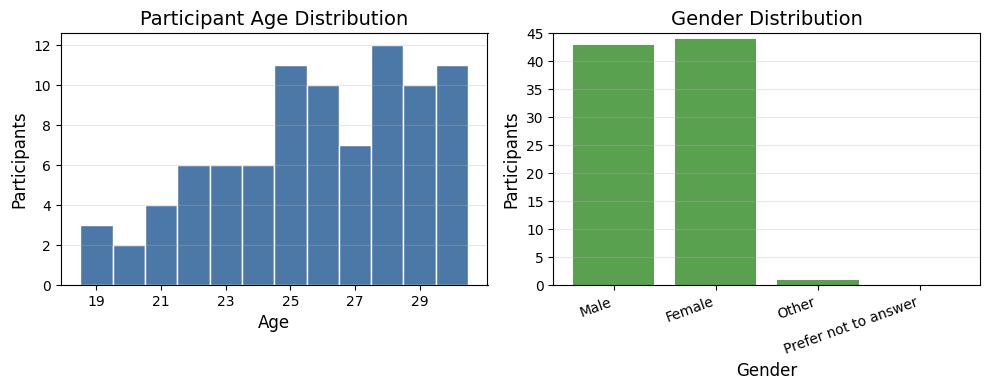

In [1415]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
bins = np.arange(
    demographics_df['age'].min() - 0.5,
    demographics_df['age'].max() + 1.5,
    1,
)
ax[0].hist(demographics_df['age'].dropna(), bins=bins, color='#4c78a8', edgecolor='white')
ax[0].set_xlabel('Age', fontsize=12)
ax[0].set_ylabel('Participants', fontsize=12)
ax[0].set_title('Participant Age Distribution', fontsize=14)
ax[0].set_xticks(np.arange(demographics_df['age'].min(), demographics_df['age'].max() + 1, 2))
ax[0].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/age_histogram.png', dpi=150)

gender_counts = demographics_df['gender'].value_counts().reindex(gender_map.values(), fill_value=0)
ax[1].bar(gender_counts.index, gender_counts.values, color='#59a14f')
ax[1].set_xlabel('Gender', fontsize=12)
ax[1].set_ylabel('Participants', fontsize=12)
ax[1].set_title('Gender Distribution', fontsize=14)
ax[1].set_ylim(0, max(gender_counts.max() + 1, 1))
ax[1].grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('figures/gender_distribution.png', dpi=150)
plt.show()

## Correct Filtering (FINAL ALGO)

In [1416]:
filtered_p0ids = df[df['session'] == 0]['prolific_pid'].unique()
filtered_p1ids = df[df['session'] == 1]['prolific_pid'].unique()
filtered_p2ids = df[df['session'] == 2]['prolific_pid'].unique()
filtered_participants = set(filtered_p0ids) & set(filtered_p1ids) & set(filtered_p2ids)
filtered_df = df[(df['prolific_pid'].isin(filtered_participants)) & (df['session'] >= 1)]
print(filtered_df[filtered_df['session'] == 1]['prolific_pid'].nunique())
print(filtered_df[filtered_df['session'] == 2]['prolific_pid'].nunique())
print(filtered_df[filtered_df['session'] == 3]['prolific_pid'].nunique())
print(filtered_df[filtered_df['session'] == 4]['prolific_pid'].nunique())

54
54
42
24


In [1417]:
sessions_1_to_4 = df[df['session'].between(1, 4)]

session_condition_info = sessions_1_to_4[
    sessions_1_to_4['prolific_pid'].isin(filtered_participants)
][['prolific_pid', 'session', 'initiation_condition']].drop_duplicates()

condition_session_counts = (
    session_condition_info
    .groupby(['prolific_pid', 'initiation_condition'], as_index=False)['session']
    .nunique()
)

matching_participant_conditions = condition_session_counts[
    condition_session_counts['session'] >= 2
][['prolific_pid', 'initiation_condition']]

filtered_df_2 = sessions_1_to_4.merge(
    matching_participant_conditions,
    on=['prolific_pid', 'initiation_condition'],
    how='inner',
)

print(f"Participants included: {filtered_df_2['prolific_pid'].nunique()}")
print(f"Sessions included: {filtered_df_2[['prolific_pid', 'session']].drop_duplicates().shape[0]}")
print(
    filtered_df_2[['prolific_pid', 'session', 'initiation_condition']]
    .drop_duplicates()
    .groupby('initiation_condition')['prolific_pid']
    .nunique()
)


Participants included: 54
Sessions included: 174
initiation_condition
free       14
primacy    19
recency    21
Name: prolific_pid, dtype: int64


In [1418]:
df_temp = filtered_df[['prolific_pid', 'initiation_condition', 'session']].drop_duplicates()

counts = (
    df_temp.groupby('prolific_pid')['initiation_condition']
    .unique().explode().value_counts()
)

print(counts)

initiation_condition
recency    21
primacy    19
free       14
Name: count, dtype: int64


In [1419]:
primacy_df = filtered_df[filtered_df['initiation_condition'] == 'primacy']
primacy_age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
primacy_age = primacy_df[['prolific_pid']].drop_duplicates().merge(primacy_age_df, on='prolific_pid', how='left')['age']
primacy_age.describe()

count    19.000000
mean     25.947368
std       3.045464
min      19.000000
25%      25.000000
50%      26.000000
75%      28.000000
max      30.000000
Name: age, dtype: float64

In [1420]:
recency_df = filtered_df[filtered_df['initiation_condition'] == 'recency']
recency_age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
recency_age = recency_df[['prolific_pid']].drop_duplicates().merge(recency_age_df, on='prolific_pid', how='left')['age']
recency_age.describe()

count    21.000000
mean     26.142857
std       3.150964
min      21.000000
25%      24.000000
50%      25.000000
75%      29.000000
max      30.000000
Name: age, dtype: float64

In [1421]:
free_df = filtered_df[filtered_df['initiation_condition'] == 'free']
free_age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
free_age = free_df[['prolific_pid']].drop_duplicates().merge(free_age_df, on='prolific_pid', how='left')['age']
free_age.describe()

count    14.000000
mean     25.642857
std       2.898465
min      21.000000
25%      23.250000
50%      25.500000
75%      28.000000
max      30.000000
Name: age, dtype: float64

## F7(a-b). Serial Position Curve (SPC)

In [1422]:
spc_df = spc.spc_df(filtered_df)
sp_cols = [c for c in spc_df.columns if c.startswith('sp_')]
spc_df.head(5)

,prolific_pid,session,initiation_condition,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,sp_7,...,sp_11,sp_12,sp_13,sp_14,sp_15,sp_16,sp_17,sp_18,sp_19,sp_20
0,5afeea460437f000017e0c97,1,primacy,1.000000,0.916667,0.500000,0.500000,0.250000,0.333333,0.250000,...,0.166667,0.083333,0.166667,0.166667,0.250000,0.166667,0.333333,0.583333,0.666667,0.750000
1,5afeea460437f000017e0c97,2,primacy,0.750000,1.000000,0.666667,0.166667,0.000000,0.250000,0.333333,...,0.166667,0.083333,0.166667,0.500000,0.333333,0.333333,0.416667,0.500000,0.416667,0.500000
2,5afeea460437f000017e0c97,3,primacy,1.000000,1.000000,0.916667,0.333333,0.083333,0.083333,0.000000,...,0.166667,0.333333,0.333333,0.166667,0.250000,0.333333,0.500000,0.500000,0.416667,0.833333
3,5afeea460437f000017e0c97,4,primacy,0.916667,0.833333,0.666667,0.666667,0.583333,0.083333,0.083333,...,0.583333,0.083333,0.250000,0.166667,0.500000,0.250000,0.250000,0.333333,0.583333,0.916667
4,5c8ec49f692c610001e14eca,1,primacy,1.000000,1.000000,1.000000,0.416667,0.166667,0.166667,0.083333,...,0.166667,0.000000,0.083333,0.250000,0.166667,0.166667,0.333333,0.416667,0.583333,1.000000


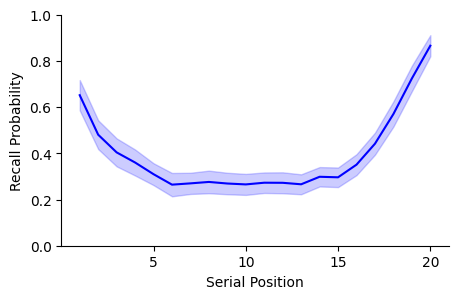

In [1423]:
overall_spc = spc.spc_plot_overall(spc_df, path=f'figures/7a_spc_overall.pdf')

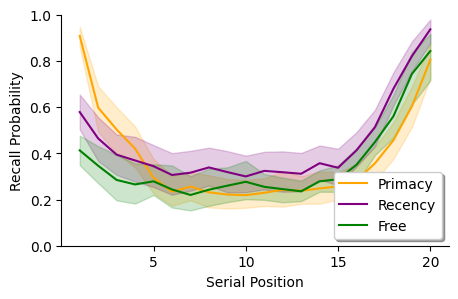

In [1424]:
spc_bycond = spc.spc_plot(spc_df, path=f'figures/7b_spc_by_condition.pdf')

In [1425]:
participant_curves = spc_df.groupby(['prolific_pid', 'initiation_condition'], as_index=False)[sp_cols].mean()

curves = participant_curves[sp_cols].to_numpy()

left_half = curves[:, :10]
right_half_reversed = curves[:, 10:][:, ::-1]

participant_curves['spc_asymmetry'] = (left_half - right_half_reversed).mean(axis=1)
stat_result = stat_tests.one_sample(participant_curves, ['spc_asymmetry'])
print(stat_result)

  initiation_condition        measure        test   n    t_stat     p_val  \
0              primacy  spc_asymmetry  one_sample  19  0.694370  0.496315   
1              recency  spc_asymmetry  one_sample  21 -5.025075  0.000065   
2                 free  spc_asymmetry  one_sample  14 -2.834765  0.014062   

   dof   cohen_d  p_val_holm  
0   18  0.159299    0.496315  
1   20 -1.096561    0.000195  
2   13 -0.757623    0.028123  


## F7(c): Linear Regression Gradient Trend

In [1426]:
linreg_df = spc_df.apply(linreg.prim_rec_lr, axis=1)
linreg_df.head(5)

,prolific_pid,session,initiation_condition,prim_slope,prim_intercept,rec_slope,rec_intercept
0,5afeea460437f000017e0c97,1,primacy,-0.191667,1.208333,0.150000,0.050000
1,5afeea460437f000017e0c97,2,primacy,-0.233333,1.216667,0.033333,0.333333
2,5afeea460437f000017e0c97,3,primacy,-0.250000,1.416667,0.091667,0.241667
3,5afeea460437f000017e0c97,4,primacy,-0.083333,0.983333,0.166667,-0.033333
4,5c8ec49f692c610001e14eca,1,primacy,-0.225000,1.391667,0.191667,-0.075000


In [1427]:
stat_tests.one_sample(linreg_df, ["prim_slope", "rec_slope"])

,initiation_condition,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,primacy,prim_slope,one_sample,19,-12.600306,2.290816e-10,18,-2.890708,1.374490e-09
1,primacy,rec_slope,one_sample,19,10.233217,6.256189e-09,18,2.347661,3.128095e-08
2,recency,prim_slope,one_sample,21,-5.628925,1.648875e-05,20,-1.228332,3.297751e-05
3,recency,rec_slope,one_sample,21,9.111349,1.477237e-08,20,1.988259,5.908949e-08
4,free,prim_slope,one_sample,14,-4.174473,1.090243e-03,13,-1.115675,1.090243e-03
5,free,rec_slope,one_sample,14,9.853551,2.134585e-07,13,2.633472,6.403754e-07


In [1428]:
stat_tests.condition_contrast(linreg_df, ["prim_slope", "rec_slope"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,prim_slope,welch,primacy vs free,19,14,14,-7.582753,1.658283e-08,30.548528,-2.503027,9.949697e-08
1,prim_slope,welch,recency vs free,21,14,14,-1.651268,1.081803e-01,32.964752,-0.528263,4.327213e-01
2,prim_slope,welch,primacy vs recency,19,21,19,-5.609853,2.109650e-06,37.058981,-1.781398,1.054825e-05
3,rec_slope,welch,primacy vs free,19,14,14,0.063198,9.500298e-01,29.889970,0.021835,1.000000e+00
4,rec_slope,welch,recency vs free,21,14,14,0.383746,7.036434e-01,32.795822,0.123801,1.000000e+00
5,rec_slope,welch,primacy vs recency,19,21,19,-0.329831,7.433610e-01,37.539185,-0.103305,1.000000e+00


In [1429]:
linreg_df.groupby("prolific_pid")["initiation_condition"].nunique().value_counts()

initiation_condition
1    54
Name: count, dtype: int64

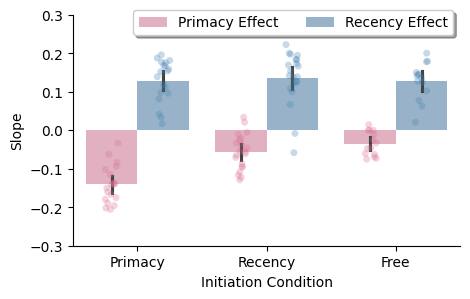

In [1430]:
linreg_plot = linreg.plot_linreg(linreg_df, path=f'figures/7c_prim_rec_slopes.pdf')

## F7(d): PFR

In [1431]:
pfr_df = pfr.pfr(filtered_df)
pfr_df.head(5)

,prolific_pid,session,initiation_condition,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,sp_7,...,sp_11,sp_12,sp_13,sp_14,sp_15,sp_16,sp_17,sp_18,sp_19,sp_20
0,5afeea460437f000017e0c97,1,primacy,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5afeea460437f000017e0c97,2,primacy,0.888889,0.0,0.111111,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5afeea460437f000017e0c97,3,primacy,0.916667,0.0,0.083333,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5afeea460437f000017e0c97,4,primacy,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5c8ec49f692c610001e14eca,1,primacy,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


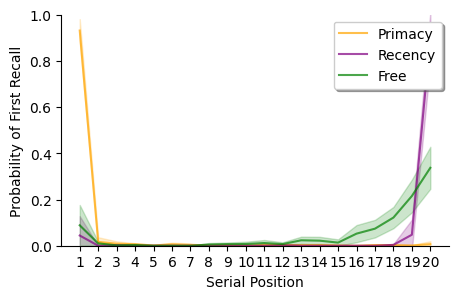

In [1432]:
pfr.pfr_plot(pfr_df, path=f'figures/7d_pfr_by_condition.pdf')

In [1433]:
# average sessions within participant-condition first
participant_df = (
    pfr_df
    .groupby(["prolific_pid", "initiation_condition"], as_index=False)
    [[f"sp_{i}" for i in range(1, 21)]]
    .mean()
)

# create grouped serial-position bins
participant_df["SP 1-3"] = participant_df[[f"sp_{i}" for i in range(1, 4)]].sum(axis=1)
participant_df["SP 18-20"] = participant_df[[f"sp_{i}" for i in range(18, 21)]].sum(axis=1)

binned_percent = (
    participant_df
    .groupby("initiation_condition")[["SP 1-3", "SP 18-20"]]
    .mean()
    .reset_index()
)

binned_percent

,initiation_condition,SP 1-3,SP 18-20
0,free,0.099937,0.674369
1,primacy,0.956858,0.010088
2,recency,0.046561,0.951455


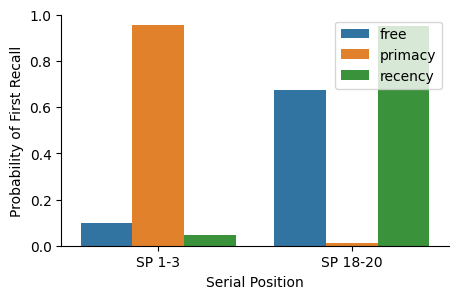

In [1434]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = binned_percent.melt(
    id_vars="initiation_condition",
    var_name="serial_position_bin",
    value_name="prob_first_recall"
)

plt.figure(figsize=(5, 3))

sns.barplot(
    data=plot_df,
    x="serial_position_bin",
    y="prob_first_recall",
    hue="initiation_condition",
)

plt.xlabel("Serial Position")
plt.ylabel("Probability of First Recall")
plt.ylim(0, 1)
plt.legend(loc='upper right')
sns.despine()
plt.show()


## F8(a-b): Mean words recalled

For each session, `mwr_sess` returns the average number of correct recalls
per list.

In [1435]:
mwr_df = mwr.mwr(filtered_df)
mwr_df.head(5)

,prolific_pid,session,initiation_condition,mwr
0,5afeea460437f000017e0c97,1,primacy,7.750000
1,5afeea460437f000017e0c97,2,primacy,6.833333
2,5afeea460437f000017e0c97,3,primacy,8.000000
3,5afeea460437f000017e0c97,4,primacy,8.250000
4,5c8ec49f692c610001e14eca,1,primacy,7.083333


In [1436]:
# Mean words recalled, averaged within participant first, then across participants by condition
mwr_participant = stat_tests.participant_condition_mean(mwr_df, ["mwr"])

mwr_summary = (
    mwr_participant
    .groupby("initiation_condition")["mwr"]
    .agg(mean="mean", sd="std", sem=lambda x: x.std(ddof=1) / np.sqrt(len(x)), n="count")
)

mwr_summary

,mean,sd,sem,n
initiation_condition,,,,
free,7.078869,1.466576,0.391959,14
primacy,7.601608,2.044742,0.469096,19
recency,8.742394,2.997058,0.654012,21


In [1437]:
mwr_df.groupby(["prolific_pid", "initiation_condition"])["mwr"].describe()

,,count,mean,std,min,25%,50%,75%,max
prolific_pid,initiation_condition,,,,,,,,
5afeea460437f000017e0c97,primacy,4.0,7.708333,0.618017,6.833333,7.520833,7.875000,8.062500,8.250000
5c8ec49f692c610001e14eca,primacy,4.0,7.229167,0.740292,6.250000,6.875000,7.375000,7.729167,7.916667
5e4adda1fb8d9f03ca4c30f7,recency,3.0,6.361111,1.380251,4.916667,5.708333,6.500000,7.083333,7.666667
5e6e93825712a9456c70a80d,primacy,3.0,5.805556,0.756148,5.000000,5.458333,5.916667,6.208333,6.500000
62b33e2a447824fbd0770025,free,3.0,6.138889,1.253698,5.333333,5.416667,5.500000,6.541667,7.583333
64010f32f8dee9772983c7cd,recency,3.0,7.472222,0.542201,6.916667,7.208333,7.500000,7.750000,8.000000
650356574411960c9f161662,primacy,2.0,6.708333,0.530330,6.333333,6.520833,6.708333,6.895833,7.083333
6560ca7bb947c4f10cf53c36,primacy,2.0,6.750000,0.235702,6.583333,6.666667,6.750000,6.833333,6.916667
65cbe0e65b1fb7f50e4a4e97,recency,2.0,10.291667,0.294628,10.083333,10.187500,10.291667,10.395833,10.500000


In [1438]:
stat_tests.condition_contrast(mwr_df, ["mwr"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,mwr,welch,primacy vs free,19,14,14,0.855133,0.399041,30.991388,0.286475,0.399041
1,mwr,welch,recency vs free,21,14,14,2.181753,0.036876,30.828598,0.663230,0.110627
2,mwr,welch,primacy vs recency,19,21,19,-1.417391,0.165099,35.447513,-0.440461,0.330198


In [1439]:
mwr_sess = mwr_df[mwr_df['session'] == 4]
stat_tests.condition_contrast(mwr_sess, ["mwr"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,mwr,welch,primacy vs free,12,5,5,0.690895,0.502381,12.380029,0.300391,1.0
1,mwr,welch,recency vs free,7,5,5,0.775893,0.456120,9.804687,0.416394,1.0
2,mwr,welch,primacy vs recency,12,7,7,-0.192278,0.850627,12.443535,-0.092029,1.0


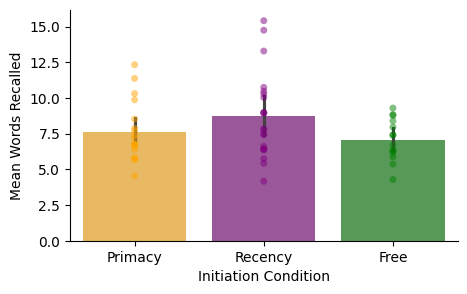

In [1440]:
mwr.mwr_plot(mwr_df, path=f'figures/8a_mwr_by_condition.pdf')

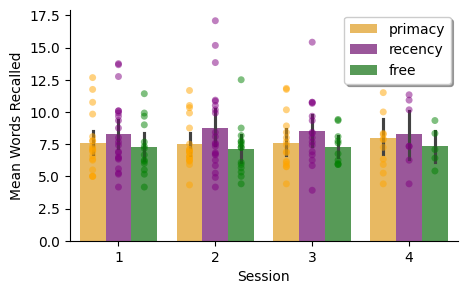

In [1441]:
mwr.mwr_plot_by_session(mwr_df, path=f'figures/8b_mwr_by_condition_by_session.pdf')

## F9(a-b) R1 Intrusion Probability

In [1442]:
r1_intrusion_data = r1_intrusion.r1_intrusion_df(filtered_df)
r1_intrusion_data.head(5)

,prolific_pid,session,initiation_condition,prop_wrong
0,5afeea460437f000017e0c97,1,primacy,0.000000
1,5afeea460437f000017e0c97,2,primacy,0.166667
2,5afeea460437f000017e0c97,3,primacy,0.000000
3,5afeea460437f000017e0c97,4,primacy,0.250000
4,5c8ec49f692c610001e14eca,1,primacy,0.000000


In [1443]:
summary = (
    r1_intrusion_data
    .groupby("initiation_condition")["prop_wrong"]
    .agg(mean="mean", sd="std")
)

print(summary)

                          mean        sd
initiation_condition                    
free                  0.056202  0.069771
primacy               0.041667  0.067384
recency               0.032051  0.063691


In [1444]:
stat_tests.condition_contrast(r1_intrusion_data, ["prop_wrong"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,prop_wrong,welch,primacy vs free,19,14,14,-0.631649,0.533053,26.375863,-0.226146,1.0
1,prop_wrong,welch,recency vs free,21,14,14,-0.929960,0.359541,31.158773,-0.309480,1.0
2,prop_wrong,welch,primacy vs recency,19,21,19,0.402191,0.689866,36.863634,0.125560,1.0


In [1445]:
for sess in range(1,5):
    r1_intrusion_prim = r1_intrusion_data[(r1_intrusion_data['session'] == sess) & (r1_intrusion_data['initiation_condition'] == 'primacy')]['prop_wrong'].mean()
    print(f'Session {sess} - Primacy: = {r1_intrusion_prim:.3f}')
    r1_intrusion_rec = r1_intrusion_data[(r1_intrusion_data['session'] == sess) & (r1_intrusion_data['initiation_condition'] == 'recency')]['prop_wrong'].mean()
    print(f'Session {sess} - Recency: = {r1_intrusion_rec:.3f}')

Session 1 - Primacy: = 0.018
Session 1 - Recency: = 0.044
Session 2 - Primacy: = 0.057
Session 2 - Recency: = 0.032
Session 3 - Primacy: = 0.036
Session 3 - Recency: = 0.026
Session 4 - Primacy: = 0.062
Session 4 - Recency: = 0.012


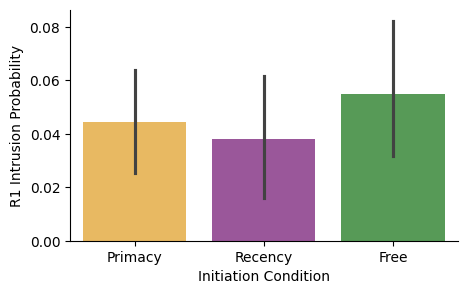

In [1446]:
r1_intrusion.r1_intrusion_overall(r1_intrusion_data, path=f'figures/9a_r1_intrusion_overall.pdf')

## F9(c) R1 Response Time

In [1447]:
rt_init_df = rt_init.rt_init_df(filtered_df)
rt_init_df.head(5)

,prolific_pid,session,initiation_condition,rt_initial
0,5afeea460437f000017e0c97,1,primacy,1543.383333
1,5afeea460437f000017e0c97,2,primacy,7568.622222
2,5afeea460437f000017e0c97,3,primacy,1733.908333
3,5afeea460437f000017e0c97,4,primacy,290.000000
4,5c8ec49f692c610001e14eca,1,primacy,988.775000


In [1448]:
rt_init_df.groupby("initiation_condition")["rt_initial"].agg(mean="mean", sd="std")

,mean,sd
initiation_condition,,
free,1697.949264,1710.655424
primacy,2418.573428,1957.108789
recency,1425.083582,1414.836844


In [1449]:
stat_tests.condition_contrast(rt_init_df, ["rt_initial"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,rt_initial,welch,primacy vs free,19,14,14,1.502934,0.143079,30.686317,0.512188,0.286157
1,rt_initial,welch,recency vs free,21,14,14,-0.342239,0.734603,29.433527,-0.116301,0.734603
2,rt_initial,welch,primacy vs recency,19,21,19,1.920262,0.062794,35.913323,0.612366,0.188382


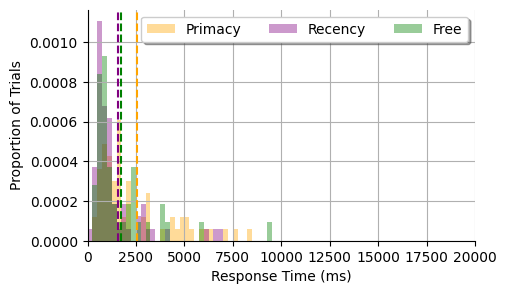

In [1450]:
rt_init_plot = rt_init.rt_init_plot(rt_init_df, path=f'figures/9b_rt_init.pdf')

## F10(A-B) PLIs and ELIs

In [1451]:
import importlib
importlib.reload(pli_eli)

<module 'analyses.pli_eli' from '/Users/andrew_wong/RecallInitiation2026/analyses/pli_eli.py'>

In [1452]:
plieli_df = pli_eli.intrusion_rates(filtered_df)
plieli_df.head(10)

,prolific_pid,session,initiation_condition,eli,pli
0,5afeea460437f000017e0c97,1,primacy,1.250000,0.125000
1,5afeea460437f000017e0c97,2,primacy,1.500000,0.000000
2,5afeea460437f000017e0c97,3,primacy,0.583333,0.250000
3,5afeea460437f000017e0c97,4,primacy,1.000000,0.166667
4,5c8ec49f692c610001e14eca,1,primacy,0.250000,0.000000
5,5c8ec49f692c610001e14eca,2,primacy,0.333333,0.125000
6,5c8ec49f692c610001e14eca,3,primacy,0.083333,0.000000
7,5c8ec49f692c610001e14eca,4,primacy,0.250000,0.000000
8,5e4adda1fb8d9f03ca4c30f7,1,recency,1.083333,0.500000
9,5e4adda1fb8d9f03ca4c30f7,2,recency,1.166667,0.375000


In [1453]:
plieli_recency = plieli_df[plieli_df['initiation_condition']=='recency']
plieli_recency_eli = plieli_recency['eli'].tolist()
print(f"Recency ELI: {np.mean(plieli_recency_eli)}")
plieli_recency_pli = plieli_recency['pli'].tolist()
print(f"Recency PLI: {np.mean(plieli_recency_pli)}")

plieli_primacy = plieli_df[plieli_df['initiation_condition']=='primacy']
plieli_primacy_eli = plieli_primacy['eli'].tolist()
print(f"Primacy ELI: {np.mean(plieli_primacy_eli)}")
plieli_primacy_pli = plieli_primacy['pli'].tolist()
print(f"Primacy PLI: {np.mean(plieli_primacy_pli)}")


Recency ELI: 1.6276068376068376
Recency PLI: 0.4784798534798535
Primacy ELI: 0.5640801958983777
Primacy PLI: 0.1443903318903319


In [1454]:
stat_tests.condition_contrast(plieli_df, ['pli','eli'], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,pli,welch,primacy vs free,19,14,14,-1.764348,0.095979,16.677936,-0.691624,0.479894
1,pli,welch,recency vs free,21,14,14,0.850146,0.401714,31.232326,0.259600,0.803429
2,pli,welch,primacy vs recency,19,21,19,-2.112337,0.046160,22.150711,-0.638426,0.276958
3,eli,welch,primacy vs free,19,14,14,-1.423964,0.177575,13.252607,-0.585217,0.710299
4,eli,welch,recency vs free,21,14,14,-0.446615,0.659242,23.493734,-0.161532,0.803429
5,eli,welch,primacy vs recency,19,21,19,-1.372912,0.184315,20.924725,-0.413833,0.710299


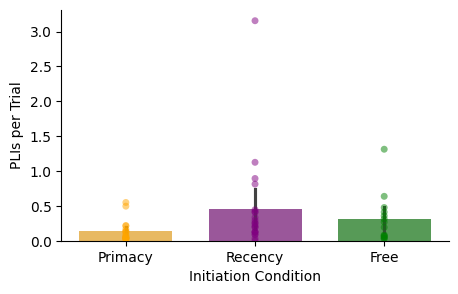

In [1455]:
pli_eli.pli_plot_overall(plieli_df, path=f'figures/10a_pli.pdf')

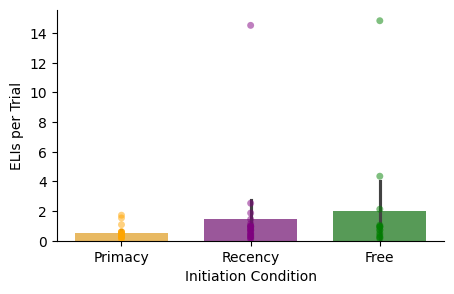

In [1456]:
pli_eli.eli_plot_overall(plieli_df, path=f'figures/10b_eli.pdf')

In [1457]:
for sess in range(1,5):
    plieli_sess = plieli_df[plieli_df['session']==sess]
    print(f'Session {sess}')
    print(stat_tests.condition_contrast(plieli_sess, ['pli','eli'], paired=False))

Session 1
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     pli  welch     primacy vs free   19   14  14 -2.046151  0.059914   
1     pli  welch     recency vs free   21   14  14  0.556948  0.581854   
2     pli  welch  primacy vs recency   19   21  19 -3.214490  0.003959   
3     eli  welch     primacy vs free   19   14  14 -1.530361  0.149381   
4     eli  welch     recency vs free   21   14  14 -0.782792  0.444226   
5     eli  welch  primacy vs recency   19   21  19 -1.623980  0.118264   

         dof   cohen_d  p_val_holm  
0  14.062840 -0.830315    0.299569  
1  28.881316  0.190412    0.888452  
2  22.219255 -0.971679    0.023754  
3  13.287807 -0.628582    0.473056  
4  17.479835 -0.305500    0.888452  
5  22.572292 -0.491267    0.473056  
Session 2
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     pli  welch     primacy vs free   19   14  14 -1.045045  0.306226   
1     pli  welch     recency vs free   21   14  14  0.

## F10(C): Final IRTs

In [1458]:
irt_final_df = irt.irt_final_df(filtered_df, n_final=4)
irt_final_df.head(5)

,prolific_pid,session,initiation_condition,relative_output_position,irt
0,5afeea460437f000017e0c97,1,primacy,-4.0,1043.071429
1,5afeea460437f000017e0c97,1,primacy,-3.0,2548.555556
2,5afeea460437f000017e0c97,1,primacy,-2.0,2246.583333
3,5afeea460437f000017e0c97,1,primacy,-1.0,5477.466667
4,5afeea460437f000017e0c97,1,primacy,0.0,16097.891667


In [1459]:
for pos in range(0,5):
    print(f'Position -{pos}')
    print(stat_tests.condition_contrast(irt_final_df[irt_final_df['relative_output_position']==-1*pos], ['irt'], paired=False))

Position -0
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     irt  welch     primacy vs free   19   14  14  0.844916  0.405338   
1     irt  welch     recency vs free   21   14  14  0.070324  0.944557   
2     irt  welch  primacy vs recency   19   21  19  0.981706  0.333286   

         dof   cohen_d  p_val_holm  
0  27.926904  0.298295    0.999857  
1  22.477525  0.025722    0.999857  
2  33.480930  0.315145    0.999857  
Position -1
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     irt  welch     primacy vs free   19   14  14  0.682554  0.500763   
1     irt  welch     recency vs free   21   14  14  0.576759  0.568947   
2     irt  welch  primacy vs recency   19   21  19  0.131603  0.895998   

         dof   cohen_d  p_val_holm  
0  26.723999  0.243628         1.0  
1  26.624685  0.201885         1.0  
2  37.711187  0.041636         1.0  
Position -2
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \


In [1460]:
summary = (
    irt_final_df
    .groupby(["initiation_condition", "relative_output_position"])["irt"]
    .agg(mean="mean", sd="std")
    .reset_index()
)

print(summary)

   initiation_condition  relative_output_position         mean           sd
0                  free                      -4.0  2776.428804  1788.456666
1                  free                      -3.0  2543.485027  1074.142296
2                  free                      -2.0  3282.020603  1624.017714
3                  free                      -1.0  4541.108299  2891.692893
4                  free                       0.0  6802.965909  4155.499655
5               primacy                      -4.0  2741.359134  1551.570044
6               primacy                      -3.0  3418.526849  2059.667814
7               primacy                      -2.0  3770.565126  2150.630198
8               primacy                      -1.0  5043.841592  2760.154013
9               primacy                       0.0  8417.378237  4574.018280
10              recency                      -4.0  3068.323645  1769.198372
11              recency                      -3.0  3479.581686  1513.538260
12          

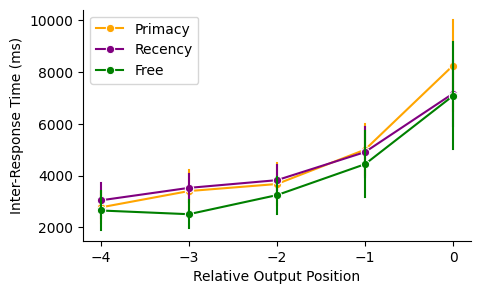

In [1461]:
irt.irt_final_plot(irt_final_df, 5, path=f'figures/10c_irt_final.pdf')

In [1462]:
irt_tot_df = irt.irt_tot_df(filtered_df)
irt_tot_df.head(5)

,prolific_pid,session,initiation_condition,ncr,ncr_bin,total_irt,irt_h1,irt_h2,irt_delta
0,5afeea460437f000017e0c97,1,primacy,5,2,5977.45,1177.6,3765.45,2587.85
1,5afeea460437f000017e0c97,1,primacy,6,3,13072.80,4136.4,8936.40,4800.00
2,5afeea460437f000017e0c97,1,primacy,9,4,16456.90,4383.1,9333.20,4950.10
3,5afeea460437f000017e0c97,1,primacy,11,5,60099.00,8690.1,46827.10,38137.00
4,5afeea460437f000017e0c97,2,primacy,4,2,25046.40,1730.3,23316.10,21585.80


In [1463]:
for bin in range(1, 11):
    print(f'NCR Bin {bin}')
    print(stat_tests.condition_contrast(irt_tot_df[irt_tot_df['ncr_bin']==bin], ['irt_delta'], paired=False))

NCR Bin 1
     measure   test            contrast  n_1  n_2  n    t_stat     p_val  \
0  irt_delta  welch     primacy vs free    7    7  7 -1.261343  0.245597   
1  irt_delta  welch     recency vs free    8    7  7 -0.093193  0.927174   
2  irt_delta  welch  primacy vs recency    7    8  7 -1.096677  0.302949   

         dof   cohen_d  p_val_holm  
0   7.379060 -0.674216    0.736791  
1  12.979617 -0.047874    0.927174  
2   8.479326 -0.534955    0.736791  
NCR Bin 2
     measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0  irt_delta  welch     primacy vs free   14   13  13  0.491242  0.628396   
1  irt_delta  welch     recency vs free   14   13  13 -0.162177  0.872843   
2  irt_delta  welch  primacy vs recency   14   14  14  0.514005  0.611655   

         dof   cohen_d  p_val_holm  
0  20.810842  0.185488         1.0  
1  19.405203 -0.061037         1.0  
2  25.613858  0.194275         1.0  
NCR Bin 3
     measure   test            contrast  n_1  n_2   n    t_s

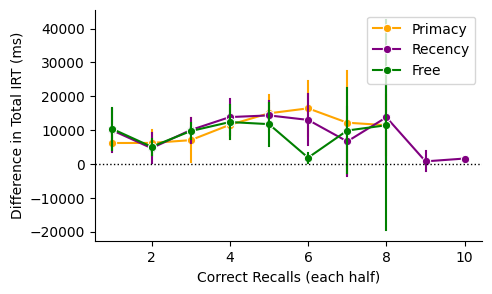

In [1464]:
irt.irt_tot_plot(irt_tot_df, path=f'figures/10e_irt_total.pdf')

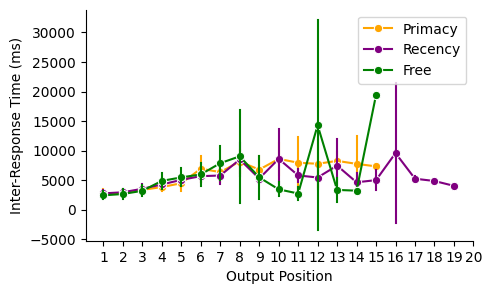

In [1465]:
irt_first_df = irt.irt_first_df(filtered_df, n_first=20)
irt.irt_first_plot(irt_first_df, n_first=20, path=f'figures/10d_irt_first.pdf')

In [1466]:
for pos in range(1, 21):
    print(f'Output Position {pos}')
    print(stat_tests.condition_contrast(irt_first_df[irt_first_df['output_position']==pos], ['irt'], paired=False))

Output Position 1
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     irt  welch     primacy vs free   19   14  14  0.796563  0.431949   
1     irt  welch     recency vs free   21   14  14  0.713057  0.481377   
2     irt  welch  primacy vs recency   19   21  19  0.123466  0.902404   

         dof   cohen_d  p_val_holm  
0  30.072886  0.274503         1.0  
1  29.695113  0.241603         1.0  
2  37.109730  0.039197         1.0  
Output Position 2
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     irt  welch     primacy vs free   19   14  14  0.254644  0.801225   
1     irt  welch     recency vs free   21   14  14  0.568959  0.575282   
2     irt  welch  primacy vs recency   19   21  19 -0.404829  0.687945   

         dof   cohen_d  p_val_holm  
0  23.377238  0.093523         1.0  
1  21.491904  0.210474         1.0  
2  36.818433 -0.128684         1.0  
Output Position 3
  measure   test            contrast  n_1  n_2   n    t_

## F11(A-B). Temporal clustering score

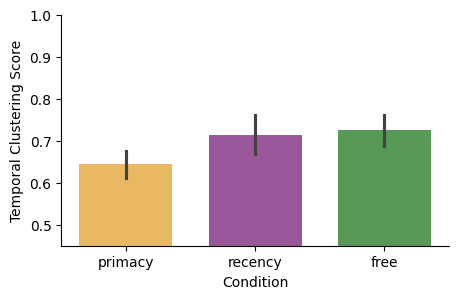

In [1467]:
tcl_df = tcl.tcl(filtered_df)
tcl.plot_tcl(tcl_df, path="figures/11a_tcl_overall.pdf")

In [1468]:
stat_tests.condition_contrast(tcl_df, ['tcl'], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,tcl,welch,primacy vs free,19,14,14,-3.237828,0.003090,28.048005,-1.141780,0.009269
1,tcl,welch,recency vs free,21,14,14,-0.341739,0.734714,32.999784,-0.108638,0.734714
2,tcl,welch,primacy vs recency,19,21,19,-2.459940,0.019026,34.688302,-0.762905,0.038053


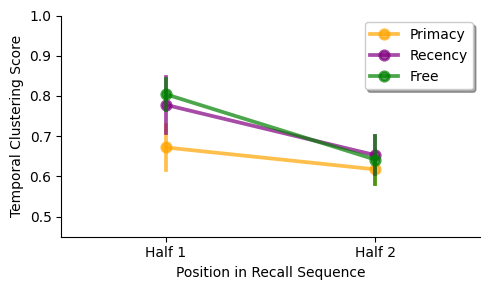

In [1469]:
tcl_h_df = tcl.tcl_h(filtered_df)
tcl.plot_tcl_h(tcl_h_df, path="figures/11b_tcl_half.pdf")

In [1470]:
stat_tests.condition_contrast(tcl_h_df, ['tcl_h1', 'tcl_h2', 'tcl_delta'], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,tcl_h1,welch,primacy vs free,19,14,14,-3.822884,0.000625,29.796446,-1.248235,0.005624
1,tcl_h1,welch,recency vs free,21,14,14,-0.648893,0.521383,29.764342,-0.195223,1.000000
2,tcl_h1,welch,primacy vs recency,19,21,19,-2.324751,0.025678,37.006595,-0.726192,0.179747
3,tcl_h2,welch,primacy vs free,19,14,14,-0.686178,0.499798,21.912157,-0.255234,1.000000
4,tcl_h2,welch,recency vs free,21,14,14,0.284392,0.778265,27.179506,0.098981,1.000000
5,tcl_h2,welch,primacy vs recency,19,21,19,-1.178575,0.246222,36.366679,-0.367274,1.000000
6,tcl_delta,welch,primacy vs free,19,14,14,2.412712,0.021992,30.749954,0.820908,0.175936
7,tcl_delta,welch,recency vs free,21,14,14,0.835125,0.409778,32.323736,0.272730,1.000000
8,tcl_delta,welch,primacy vs recency,19,21,19,1.525308,0.135487,37.888531,0.481749,0.812923


## F11(C) Lag-CRP

Lag-CRP is computed per session, then averaged within participant-condition
before plotting condition curves.


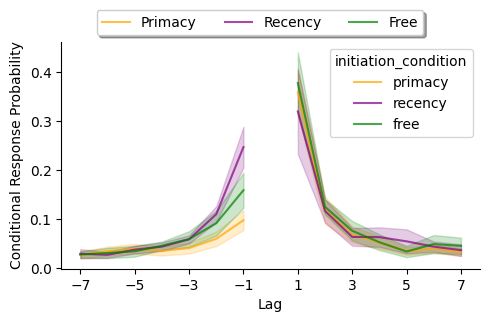

In [1471]:
lcrp_df = lcrp.lag_crp(filtered_df)
lcrp.plot_lcrp(lcrp_df, max_lag = 7, path='figures/11c_lcrp.pdf')

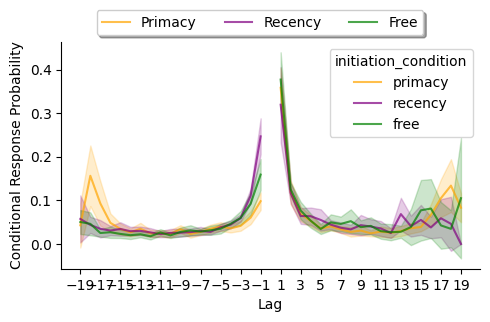

In [1472]:
lcrp.plot_lcrp(lcrp_df, max_lag = 19, path='figures/11e_lcrp_full.pdf')

In [1473]:
fwd_asym_df = lcrp_df.apply(lambda row: lcrp.forward_asymmetry(row, n=1), axis=1)

stat_tests.condition_contrast(fwd_asym_df, ["asym"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,asym,welch,primacy vs free,19,14,14,0.943557,0.356483,20.315532,0.356101,0.356483
1,asym,welch,recency vs free,21,14,14,-2.143337,0.039657,32.544825,-0.667745,0.079314
2,asym,welch,primacy vs recency,19,21,19,3.169952,0.003924,25.627541,0.964923,0.011771


In [1474]:
stat_tests.condition_contrast(lcrp_df, ["lp_1", "ln_1"], paired=False)


,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,lp_1,welch,primacy vs free,19,14,14,-0.478229,6.365984e-01,25.270000,-0.172847,0.892727
1,lp_1,welch,recency vs free,21,14,14,-1.058551,2.975758e-01,32.638686,-0.330525,0.892727
2,lp_1,welch,primacy vs recency,19,21,19,0.778179,4.425583e-01,29.999079,0.238907,0.892727
3,ln_1,welch,primacy vs free,19,14,14,-2.909233,8.376381e-03,21.040890,-1.090614,0.033506
4,ln_1,welch,recency vs free,21,14,14,3.142667,3.537203e-03,32.843578,1.012031,0.017686
5,ln_1,welch,primacy vs recency,19,21,19,-6.329397,6.660326e-07,28.820513,-1.938694,0.000004


In [1475]:
tmp = stat_tests.participant_condition_mean(lcrp_df, ["lp_1", "ln_1"])

tmp.groupby("initiation_condition")[["lp_1", "ln_1"]].agg(["mean", "sem", "count"])

stat_tests.condition_contrast(fwd_asym_df, ["asym"], paired=False)


,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,asym,welch,primacy vs free,19,14,14,0.943557,0.356483,20.315532,0.356101,0.356483
1,asym,welch,recency vs free,21,14,14,-2.143337,0.039657,32.544825,-0.667745,0.079314
2,asym,welch,primacy vs recency,19,21,19,3.169952,0.003924,25.627541,0.964923,0.011771


## F11(d) Semantic Clustering

In [1476]:
wordpool = list(np.loadtxt('data/wordpool/wordpool_ltpFR3.txt', dtype=str))
w2v_scores = np.loadtxt('data/wordpool/w2v_scores_ltpFR3.txt')

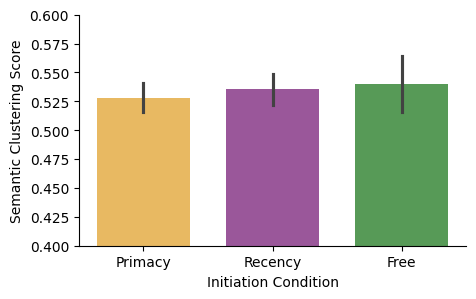

In [1477]:
scl_df = scl.scl(filtered_df, wordpool, w2v_scores)
scl.plot_scl(scl_df, path="figures/11d_scl_by_condition.pdf")

In [1478]:
stat_tests.one_sample(scl_df, ["scl"], popmean=0.5)

,initiation_condition,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,primacy,scl,one_sample,19,4.553683,0.000246,18,1.044687,0.000492
1,recency,scl,one_sample,21,5.256348,0.000038,20,1.147029,0.000115
2,free,scl,one_sample,14,3.240615,0.006444,13,0.866091,0.006444


In [1479]:
# 3) stats
stat_tests.condition_contrast(scl_df, ["scl"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,scl,welch,primacy vs free,19,14,14,-0.847458,0.407013,19.515863,-0.322292,1.0
1,scl,welch,recency vs free,21,14,14,-0.322216,0.750516,20.727345,-0.120296,1.0
2,scl,welch,primacy vs recency,19,21,19,-0.782605,0.438714,37.966177,-0.246120,1.0
